# Indice de contenido
1. [Importar librerias](#il)
2. [Funciones y clases auxiliares](#fca)
3. [Elegir configuracion](#ec)
    - 3.1 [Configuracion: 1 camara](#ec1)
        - 3.1.1 [Seleccionar camara](#ec1sc) 
            - 3.1.1.1 [Forma automatica](#ec1scfa)
            - 3.1.1.2 [Forma manual](#ec1scfm)
        - 3.1.2 [Capturar imagenes en dos instantes de tiempo](#ec1ci) 
    - 3.2 [Configuracion: 2 camaras](#ec2)
        - 3.2.1 [Seleccionar camaras](#ec2sc)  
            - 3.2.1.1 [Forma automatica](#ec2scfa)
            - 3.2.1.2 [Forma manual](#ec2scfm)
        - 3.2.2 [Capturar imagenes](#ec2ci)  
4. [Obtener parametros de calibracion](#opc)
5. [Obtener pares de puntos 2D correspondientes](#opp)
    - 5.1 [Forma automatica](#oppfa)
        - 5.1.1 [ORB (Oriented FAST and Rotated BRIEF)](#oppfaorb)
        - 5.1.2 [AKAZE (Accelerated KAZE)](#oppfaakaze)
        - 5.1.3 [BRISK (Binary Robust Invariant Scalable Keypoints)](#oppfabrisk)
    - 5.2 [Forma manual](#oppfm)
6. [Normalizar coordenadas en el rango \[−1,1\]](#nc)
7. [Calcular matriz esencial E](#cme)
    - 7.1 [Error de la matriz esencial](#cmee)
    - 7.2 [Lineas epipolares sobre coordenadas normalizadas](#cmeln)
    - 7.3 [Lineas epipolares sobre coordenadas originales](#cmelo)
8. [Recuperar pose relativa (R,t)](#rpr)
    - 8.1 [Comprobar solucion fisicamente correcta de forma automatica](#rpra)
    - 8.2 [Comprobar solucion fisicamente correcta de forma manual](#rprm)
9. [Resultados](#r)

# 1. Importar librerias <a class='anchor' id='il'>

In [2]:
import io
import os
import cv2
import time
import numpy as np
import pickle
import subprocess
import re
import shutil
import glob
import matplotlib
import matplotlib.pyplot as plt
import plotly
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

%matplotlib inline

In [3]:
# Versiones de los paquetes utilizados
print('Versiones de los paquetes utilizados:')
print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

Versiones de los paquetes utilizados:
cv2==4.12.0
numpy==2.4.1
re==2.2.1
matplotlib==3.10.8
plotly==6.5.0


# 2. Funciones y clases auxiliares <a class='anchor' id='fca'>

In [4]:
# Seleccionar camara
# NOTA: Solo para sistemas operativos Linux
def select_camera():
    camera_information=None
    # Camaras conectadas via USB 
    # Cada elemento de la lista cuenta con: (Nombre de la camara, Ruta de la camara)
    camera_information_list=get_camera_information_list()
    while camera_information is None:
        print('\n' + 100 * '*')
        print('\nCamaras disponibles: ')
        for i in range(len(camera_information_list)):
            print(f'\t {i + 1}) ', camera_information_list[i])
        option=input('Elige una camara: ')
        if int(option) > 0 and int(option) <= len(camera_information_list):
            camera_information=camera_information_list[int(option) - 1]
            break
    return camera_information

# Obtener informacion de las camaras conectadas via USB
def get_camera_information_list():
    camera_information_list=[]
    res=subprocess.run(["v4l2-ctl", "--list-devices"], capture_output=True, text=True)
    res_split=res.stdout.split("\n\n")[0:-1]
    pattern = "video[0-9]{1}"
    for r in res_split:
        r_split=r.split("\n\t")
        if len(re.findall(pattern, r_split[1]))>0:
            camera_name=r_split[0].split("(")[0].strip() 
            camera_path=r_split[1]
            camera_information_list.append((camera_name, camera_path))
    return camera_information_list

# Muestra la camara y toma una imagen 
def show_camera(camera_information):
    image_bgr=None
    camera_name,camera_path=camera_information
    # Abrimos la camara
    cap=cv2.VideoCapture(camera_path)
    while True:
        try:
            if cap is not None:
                if cap.isOpened():
                    # Captura de la imagen actual de la camara
                    ret, image_bgr=cap.read()
                    # Dimensiones: (height,width,deep)
                    if ret:
                        # Se muestra lo que captura la camara
                        cv2.imshow(camera_name, image_bgr)
                        key=cv2.waitKey(1)
                        
                        # Condicion de parada
                        if key == ord('q'):
                            break 
        except cv2.error as e:
            print("(cv2.error): {}".format(e))
    cap.release()
    cv2.destroyAllWindows()
    return image_bgr

# Elimina la distorsion de los puntos distorsionados
def undistorted_points(uds, K, q):
    # Obtenemos los puntos normalizados sin distorsion
    vns=cv2.undistortPoints(uds[:,None,:].astype('float32'), K, q)
    vns=vns.squeeze()
    vns_=np.concatenate([vns, np.ones((vns.shape[0],1))], axis=1)
    # Obtenemos los puntos sin distorsion sobre el plano de imagen 
    us_=(K @ vns_.T).T
    us=us_[:,[0,1]]
    return us

# Figura en 3D con Plotly
def plotly_figure(title=''):
    fig = go.Figure(data=[])
    fig.update_layout(
        scene=dict(
            xaxis_title='x',
            yaxis_title='y',
            zaxis_title='z',
            # xaxis = dict(nticks=None, range=[-1,1]),
            # yaxis = dict(nticks=None, range=[-1,1]),
            # zaxis = dict(nticks=None, range=[-1,1]),
            # aspectmode='cube',
            # aspectratio=dict(x=1, y=1, z=1),
            camera=dict(
                eye=dict(x=1.5, y=-1.5, z=1.5) 
            )
        ),
        title=dict(
            text=title,
            font=dict(
                family="Arial",
                size=24,
                color="red"
            ),
            x=0.5, 
            xanchor="center"
        ), 
        autosize=False,
        width=800, 
        height=500,
        margin=dict(l=40, r=40, b=40, t=40),
        showlegend=False,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            font=dict(
                family="Courier",
                size=14,
                color="black"
            ),
            itemsizing="constant"
        )
    )
    return fig

# Dibujar sistema de coordenadas 
def plot_coordinate_system(fig, Tsm, tsm, text='', subprefix=''):
    axis_color=['red','green','blue']
    axis_name=['X','Y','Z']
    cs=np.array([[0,0,0,1],[1,0,0,1],[0,1,0,1],[0,0,1,1]]).T
    Hsm=np.concatenate([np.concatenate([Tsm, tsm], axis=1), np.array([[0,0,0,1]])], axis=0)
    ps=(Hsm @ cs)[0:3,:]
    # Puntos
    fig.add_scatter3d(
        x=ps[0,:], 
        y=ps[1,:], 
        z=ps[2,:], 
        mode='markers', 
        marker=dict(size=6, symbol="circle", color='black'),
    )
    # Nombre de los ejes
    for j in range(3):
        fig.add_scatter3d(
            x=[ps[0,1 + j]], 
            y=[ps[1,1 + j]], 
            z=[ps[2,1 + j]], 
            mode='text', 
            text=f'{axis_name[j]}<sub>{subprefix}</sub>'
        )
    # Texto
    fig.add_scatter3d(
        x=[ps[0,0]], 
        y=[ps[1,0]], 
        z=[ps[2,0]], 
        mode='text', 
        text=text,
    )
    # Lineas
    for j in range(3):
        fig.add_scatter3d(
            x=[ps[0,0],ps[0,j+1]], 
            y=[ps[1,0],ps[1,j+1]], 
            z=[ps[2,0],ps[2,j+1]], 
            mode='lines', 
            line=dict(width=5, color=axis_color[j])
        )
    return fig

# Mostrar imagenes
def plot_images(image_bgr_1, image_bgr_2, title='', figsize=(4,4)):
    image_rgb=cv2.cvtColor(cv2.hconcat([image_bgr_1, image_bgr_2]), cv2.COLOR_BGR2RGB)
    fig=plt.figure(figsize=figsize)
    plt.title(f'{title}')
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

# Obtener los parametros de calibracion de la camara
def get_calibration_parameters(camera_information):
    calibration_parameters=None
    # Informacion de la camara
    camera_name,camera_path=camera_information
    # Ruta al archivo
    path=os.path.join(os.getcwd(), *['calibration parameters', camera_name, 'calibration_parameters.dat'])
    try:
        with open(path, "rb") as f:
            calibration_parameters=pickle.load(f)
    except (OSError, IOError) as e:
        pass
    return calibration_parameters

# Detecta cuando se hace click sobre una imagen
def click_event_point(event, x, y, flags, params, img, points, numerate, alternate):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x,y)) 
        color=(0,0,255) # Rojo (por defecto)
        if alternate:
            if len(points) % 2 == 0:
                color=(0,255,0) # Verde
            else:
                color=(0,0,255) # Rojo
        if numerate:
            cv2.putText(img, f'{len(points)}', (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2, cv2.LINE_AA)
        cv2.circle(img, center=(int(x), int(y)), radius=5, color=color, thickness=-1)
        cv2.imshow('image', img)

# Obtener puntos sobre una imagen
def points_from_image(img_bgr, numerate=True, alternate=False):
    img=img_bgr.copy()
    points=[]
    cv2.imshow('image', img)
    cv2.setMouseCallback('image', lambda event, x, y, flags, params: click_event_point(event, x, y, flags, params, img, points, numerate, alternate))
    while True:
        k = cv2.waitKey(1) 
        if k == ord('q'): 
            break
    cv2.destroyAllWindows()
    cv2.waitKey(1) 
    return np.array(points)

# Seleccion a mano de puntos correspondientes en las dos camaras
def manual_corresponding_points(image_bgr_1, image_bgr_2):
    points=points_from_image(img_bgr=cv2.hconcat([image_bgr_1, image_bgr_2]), numerate=True, alternate=True)
    h,w,d=image_bgr_1.shape
    m=points.shape[0]
    points1d=np.zeros((int(m / 2),2))
    points2d=np.zeros((int(m / 2),2))
    for i in range(int(m / 2)):
        points1d[i]=points[i * 2]
        points2d[i]=points[i * 2 + 1] - np.array([w,0])
    return points1d,points2d

# Vista de las dos camaras
def cameras_view(camera_1_information, camera_2_information):
    camera_1_name,camera_1_path=camera_1_information
    camera_2_name,camera_2_path=camera_2_information
    image_bgr_1=None
    image_bgr_2=None
    # Abrimos las camaras
    cap1=cv2.VideoCapture(camera_1_path)
    cap2=cv2.VideoCapture(camera_2_path)
    while True:
        try:
            if cap1 is not None and cap2 is not None:
                if cap1.isOpened() and cap2.isOpened():
                    # Captura de la imagen actual de cada camara
                    ret1, image_bgr_1=cap1.read()
                    ret2, image_bgr_2=cap2.read()
                    # Dimensiones: (height,width,deep)
                    if ret1 and ret2:
                        # Se muestra lo que capturan las camaras
                        cv2.imshow(f'{camera_1_name} | {camera_2_name}', cv2.hconcat([image_bgr_1, image_bgr_2]))
                        key=cv2.waitKey(1)
                        
                        # Condicion de parada
                        if key == ord('q'):
                            break 
        except cv2.error as e:
            print("(cv2.error): {}".format(e))
    cap1.release()
    cap2.release()
    cv2.destroyAllWindows()
    return image_bgr_1,image_bgr_2

# Normalizacion de las coordenadas en el rango [-1,1]
"""
Mapeo lineal entre intervalos
[0,w] -> [wa,wb]
[0,h] -> [ha,hb]
"""
def normalization_matrix(w, h, wa=-1, wb=1, ha=-1, hb=1):
    M=np.array([
        [(wb-wa)/w, 0, wa],
        [0, (hb-ha)/h, ha],
        [0, 0, 1]
    ])
    return M

# Mostrar pose relativa entre camaras
def plot_recovered_pose(T21, t21):
    # Figura 
    fig=plotly_figure(title='Recuperacion de la pose de las camaras')
    
    # Definimos como esta rotado y posicionado el sistema de coordenadas de la camara 1 con respecto al sistema de coordenadas de plotly
    T1m=np.array([[0,0,1],[-1,0,0],[0,-1,0]])
    t1m=np.zeros((3,1))
    H1m=np.vstack([np.hstack([T1m, t1m]), np.ones((1,4))])
    fig=plot_coordinate_system(fig, Tsm=T1m, tsm=t1m, text='S.C. Camara 1', subprefix='1')
    
    # Definimos como esta rotado y posicionado el sistema de coordenadas de la camara 2  con respecto al sistema de coordenadas de plotly
    H21=np.vstack([np.hstack([T21, t21]), np.ones((1,4))])
    H2m=H1m @ H21
    T2m=H2m[:3,:3]
    t2m=H2m[:3,[3]] 
    fig=plot_coordinate_system(fig, Tsm=T2m, tsm=t2m, text='S.C. Camara 2', subprefix='2')
    
    return fig    

# Recuperar pose relativa
def recover_pose(E, vns1, vns2, mask):
    # Se realiza una comprobación geométrica (cheirality check)
    # Filtramos buenas correspondencias
    filtered_vns1=vns1[mask.flatten().astype(bool)]
    filtered_vns2=vns2[mask.flatten().astype(bool)]
    # El vector de traslacion esta normalizado
    # Las matrices de rotación tienen determinante 1 (son matrices de rotacion propias)
    R1,R2,t=cv2.decomposeEssentialMat(E)
    # Para guardar las soluciones candidatas
    solutions=[None] * 4
    count=[0] * 4
    # Posibles soluciones
    for index,(T12,t12) in enumerate([
        (R1,t), 
        (R1,-t), 
        (R2,t), 
        (R2,-t)
    ]):
        # Se guarda la solucion
        solutions[index]=(T12,t12)
        # Numero de correspondencias
        N=filtered_vns1.shape[0]
        for i in range(N):
            vn1_=np.hstack([filtered_vns1[0], 1])[:,None]
            vn2_=np.hstack([filtered_vns2[0], 1])[:,None]
            A=np.array([
                [(vn2_.T @ vn2_)[0,0], (-vn2_.T @ T12 @ vn1_)[0,0]],
                [(vn1_.T @ T12.T @ vn2_)[0,0], (-vn1_.T @ vn1_)[0,0]]
            ])
            b=np.array([
                [(vn2_.T @ t12)[0,0]],
                [(vn1_.T @ T12.T @ t12)[0,0]]
            ])
            z=np.linalg.inv(A) @ b
            zc2,zc1=z.flatten()
            # if i == 0:
            #     print(zc1,zc2)
            if zc2 > 0 and zc1 > 0:
                count[index]+=1
    
    # Solucion fisicamente correcta
    T12,t12=solutions[np.argmax(count)]
    return T12,t12

# Mostrar puntos correspondientes entre dos imagenes
def plot_correspondences(image1, image2, points1, points2, figsize=(16,10), title='', p_size=5, show_text=True, t_size=3):
    img1=image1.copy()
    img2=image2.copy()
    # Numero correspondencias
    N=points1.shape[0]
    for i in range(N):
        # Color para la correspondencia
        color_bgr=tuple(np.random.randint(0,255,3,dtype='uint8').tolist())
        # Mostrar puntos
        img1=cv2.circle(img1, points1[i].astype(int), p_size, color_bgr, -1)
        img2=cv2.circle(img2, points2[i].astype(int), p_size, color_bgr, -1)
        # Mostrar texto
        if show_text:
            img1=cv2.putText(img1, f'{i + 1}', points1[i].astype(int), cv2.FONT_HERSHEY_SIMPLEX, 1, color_bgr, t_size, cv2.LINE_AA)
            img2=cv2.putText(img2, f'{i + 1}', points2[i].astype(int), cv2.FONT_HERSHEY_SIMPLEX, 1, color_bgr, t_size, cv2.LINE_AA)
    image_rgb=cv2.cvtColor(cv2.hconcat([img1, img2]), cv2.COLOR_BGR2RGB)
    fig=plt.figure(figsize=figsize)
    plt.title(title)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

# Obtener pares de puntos correspondientes entre dos imagenes
def corresponding_points(image1, image2, model):
    # Imagenes en escala de grises
    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
    
    # Detectar puntos clave y calcular descriptores para ambas imágenes
    # kp[i].pt: Punto 2D
    # des: Matriz de descriptores de dimension (<number of features>, M)
    kp1, des1 = model.detectAndCompute(gray1, None)
    kp2, des2 = model.detectAndCompute(gray2, None)
    
    # Crear el objeto BFMatcher con distancia Hamming
    # crossCheck=True asegura que el emparejamiento sea mutuo (A coincide con B y viceversa)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    
    # Realizar el emparejamiento
    # matches[i].queryIdx: Corresponde a des1 
    # matches[i].trainIdx: Corresponde a des2
    # matches[i].distance: Distancia entre los dos descriptores coincidentes
    matches = bf.match(des1, des2)
    
    # Ordenar las coincidencias por distancia (las mejores primero)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Obener puntos correspondientes
    N=len(matches)
    points1=np.zeros((N,2))
    points2=np.zeros((N,2))
    for i in range(N):
        points1[i]=kp1[matches[i].queryIdx].pt
        points2[i]=kp2[matches[i].trainIdx].pt

    return points1,points2

# 3. Elegir configuracion <a class='anchor' id='ec'>

Solo elegir una opcion de las siguientes:
- Configuracion: 1 camara
- Configuracion: 2 camaras

## 3.1 Configuracion: 1 camara <a class='anchor' id='ec1'>

En todo el proceso se hace mencion de la camara 1 y camara 2, los cuales para esta configuracion corresponden a:
- Camara 1: Imagen tomada en un instante $t$
- Camara 2: Imagen tomada en un instante $t+1$

### 3.1.1 Seleccionar camara <a class='anchor' id='ec1sc'>

Solo elegir una opcion de las siguientes:
- Forma automatica
- Forma manual

#### 3.1.1.1 Forma automatica <a class='anchor' id='ec1scfa'>

Solo funciona para sistemas operativos Linux.

In [31]:
# Seleccion de la camara
camera_information=select_camera()
print(f'\nCamara seleccionada: {camera_information}')

camera_1_information=camera_information
camera_2_information=camera_information


****************************************************************************************************

Camaras disponibles: 
	 1)  ('USB PHY 2.0: USB CAMERA', '/dev/video0')
	 2)  ('HX-USB Camera: HX-USB Camera', '/dev/video4')
	 3)  ('EasyCamera: EasyCamera', '/dev/video2')


Elige una camara:  1



Camara seleccionada: ('USB PHY 2.0: USB CAMERA', '/dev/video0')


#### 3.1.1.2 Forma manual <a class='anchor' id='ec1scfm'>

Funciona de forma general para cualquier sistema operativo, solo se requiere especificar un nombre para la camara y la ruta de la camara.

La ruta es la que se pasa como parametro a cv2.VideoCapture(\<camera path\>).

In [ ]:
camera_information=(
    'USB PHY 2.0: USB CAMERA', # Nombre de la camara
    '/dev/video0'              # Ruta de la camara
)

camera_1_information=camera_information
camera_2_information=camera_information

### 3.1.2 Capturar imagenes en dos instantes de tiempo <a class='anchor' id='ec1ci'>

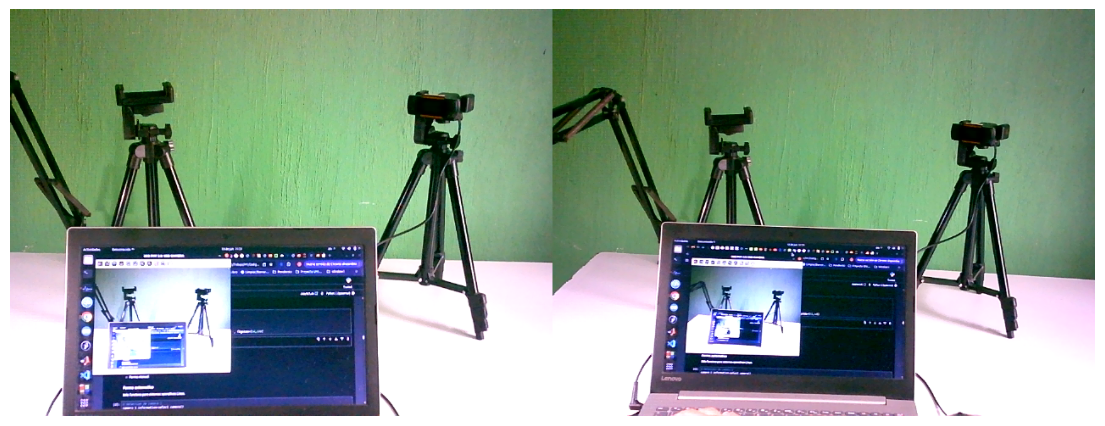

In [86]:
# Obtencion de imagenes en dos instantes de tiempo diferente
# Presionar 'q' para tomar la imagen
distorted_image_bgr_1=show_camera(camera_information)
distorted_image_bgr_2=show_camera(camera_information)

plot_images(distorted_image_bgr_1, distorted_image_bgr_2, title='', figsize=(14,14))

## 3.2 Configuracion: 2 camaras <a class='anchor' id='ec2'>

### 3.2.1 Seleccionar camaras <a class='anchor' id='ec2sc'>

Solo elegir una opcion de las siguientes:
- Forma automatica
- Forma manual

#### 3.2.1.1 Forma automatica <a class='anchor' id='ec2scfa'>

Solo funciona para sistemas operativos Linux.

In [5]:
# Seleccion de camara 1
camera_1_information=select_camera()
print(f'\nCamara 1 seleccionada: {camera_1_information}')
# Seleccion de camara 2
camera_2_information=select_camera()
print(f'\nCamara 2 seleccionada: {camera_2_information}')


****************************************************************************************************

Camaras disponibles: 
	 1)  ('USB PHY 2.0: USB CAMERA', '/dev/video0')
	 2)  ('HX-USB Camera: HX-USB Camera', '/dev/video4')
	 3)  ('EasyCamera: EasyCamera', '/dev/video2')


Elige una camara:  1



Camara 1 seleccionada: ('USB PHY 2.0: USB CAMERA', '/dev/video0')

****************************************************************************************************

Camaras disponibles: 
	 1)  ('USB PHY 2.0: USB CAMERA', '/dev/video0')
	 2)  ('HX-USB Camera: HX-USB Camera', '/dev/video4')
	 3)  ('EasyCamera: EasyCamera', '/dev/video2')


Elige una camara:  2



Camara 2 seleccionada: ('HX-USB Camera: HX-USB Camera', '/dev/video4')


#### 3.2.1.2 Forma manual <a class='anchor' id='ec2scfm'>

Funciona de forma general para cualquier sistema operativo, solo se requiere especificar un nombre para la camara y la ruta de la camara.

La ruta es la que se pasa como parametro a cv2.VideoCapture(\<camera path\>).

In [ ]:
camera_1_information=(
    'USB PHY 2.0: USB CAMERA',      # Nombre de la camara 1
    '/dev/video0'                   # Ruta de la camara 1
)
camera_2_information=(
    'HX-USB Camera: HX-USB Camera', # Nombre de la camara 2 
    '/dev/video4'                   # Ruta de la camara 2
)

### 3.2.2 Capturar imagenes <a class='anchor' id='ec2ci'>

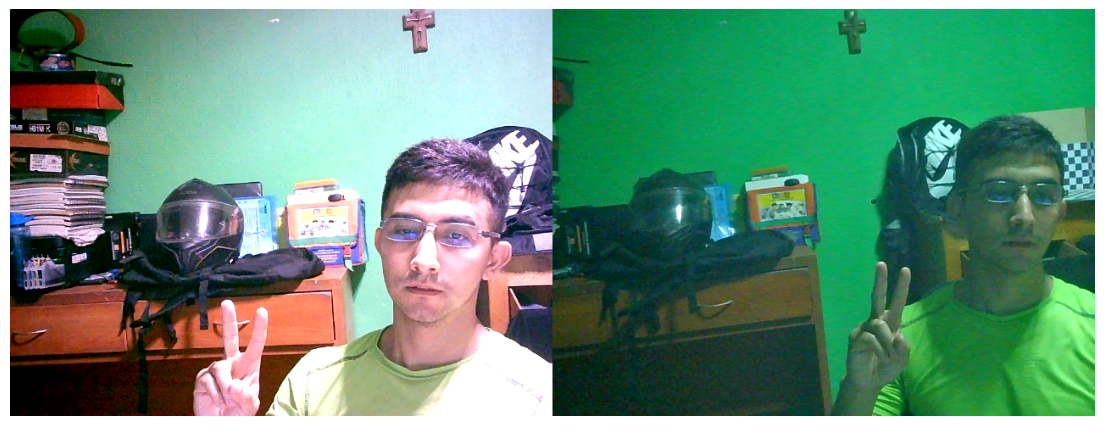

In [6]:
# Obtencion de las imagenes
# Presionar 'q' para tomar las imagenes
distorted_image_bgr_1,distorted_image_bgr_2=cameras_view(camera_1_information, camera_2_information)

plot_images(distorted_image_bgr_1, distorted_image_bgr_2, title='', figsize=(14,14))

# 4. Obtener parametros de calibracion <a class='anchor' id='opc'>

In [7]:
# Obtencion de los parametros de calibracion 
calibration_parameters_1=get_calibration_parameters(camera_1_information)
calibration_parameters_2=get_calibration_parameters(camera_2_information)

K1=calibration_parameters_1['camera']['K']
q1=calibration_parameters_1['camera']['q']
K2=calibration_parameters_2['camera']['K']
q2=calibration_parameters_2['camera']['q']

# 5. Obtener pares de puntos 2D correspondientes <a class='anchor' id='opp'>

Solo elegir una opcion de las siguientes:
- Forma automatica
- Forma manual

Enfoques:
- Enfoques basados en características (indirectos)
    - Comerciales:
        - SIFT (Scale-Invariant Feature Transform)
        - SURF (Speeded Up Robust Features)
    - Libres:
        - ORB (Oriented FAST and Rotated BRIEF)
        - AKAZE (Accelerated KAZE)
        - BRISK (Binary Robust Invariant Scalable Keypoints) 
- Enfoques directos (sin detectores): En lugar de extraer y describir puntos, minimizan el error fotométrico directamente sobre los píxeles de la imagen.
    - DSO (Direct Sparse Odometry)

## 5.1 Forma automatica <a class='anchor' id='oppfa'>

Solo elegir una opcion de las siguientes:
- ORB
- AKAZE
- BRISK

#### 5.1.1 ORB (Oriented FAST and Rotated BRIEF) <a class='anchor' id='oppfaorb'>

In [28]:
"""
Inicializar el detector ORB
- nfeatures: Número máximo de puntos clave a conservar.
- scaleFactor: Relación piramidal para la invariancia de escala.
- nlevels: Número de niveles de la pirámide.
"""
orb = cv2.ORB_create(
    nfeatures=1000, 
    scaleFactor=1.2, 
    nlevels=8
)

# Calcular puntos correspondientes entre las dos imagenes
uds1,uds2=corresponding_points(distorted_image_bgr_1, distorted_image_bgr_2, orb)

# Filtrar solo las mejores correspondencias
uds1=uds1[:100]
uds2=uds2[:100]

# Eliminacion de la distorsion
us1=undistorted_points(uds1, K1, q1)
us2=undistorted_points(uds2, K2, q2)
print(us1.shape)
print(us2.shape)

(100, 2)
(100, 2)


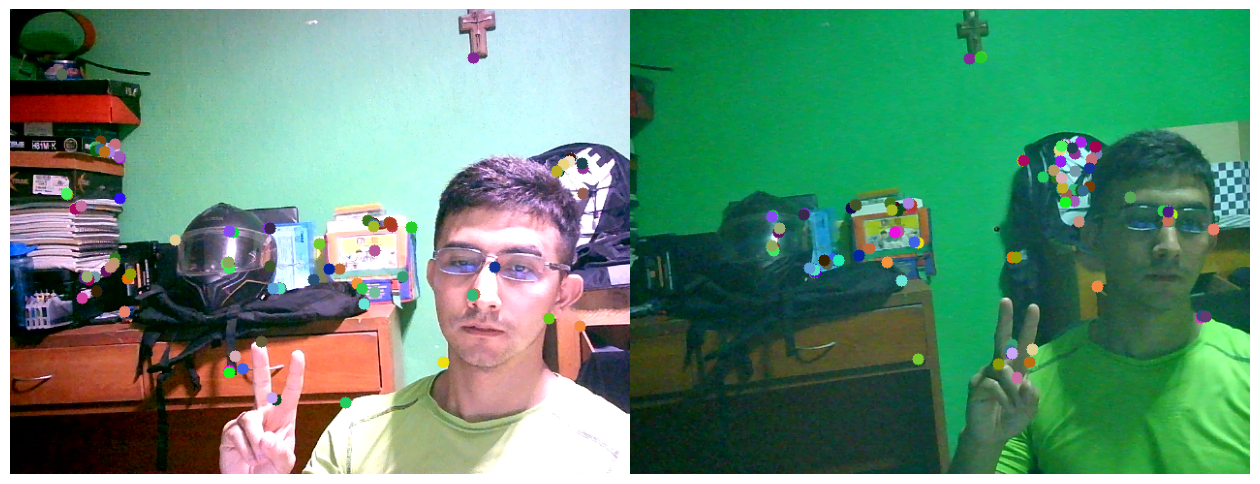

In [29]:
# Mostrar puntos correspondientes entre las dos imagenes
plot_correspondences(distorted_image_bgr_1, distorted_image_bgr_2, uds1, uds2, figsize=(16,10), title='', p_size=6, show_text=False)

#### 5.1.2 AKAZE (Accelerated KAZE) <a class='anchor' id='oppfaakaze'>

In [20]:
"""
Inicializar el detector AKAZE
- descriptor_type: Tipo de descriptor a extraer.
    - cv2.AKAZE_DESCRIPTOR_MLDB
    - cv2.AKAZE_DESCRIPTOR_MLDB_UPRIGHT
- descriptor_size: Tamaño del descriptor en bits (usar 0 para el descriptor completo).
- descriptor_channels: Número de canales para el descriptor.
- threshold: Umbral de respuesta del detector para aceptar puntos (reducir este valor extrae más puntos clave).
- nOctaves: Evolución máxima de octava del espacio de escala de la imagen.
- nOctaveLayers: Número de subniveles por capa de octava.
- diffusivity: Tipo de difusividad utilizado en la formulación del espacio de escala no lineal.
    - cv2.KAZE_DIFF_PM_G1
    - cv2.KAZE_DIFF_PM_G2
    - cv2.KAZE_DIFF_WEICKERT
    - cv2.KAZE_DIFF_CHARBONNIER
"""
akaze = cv2.AKAZE_create(
    descriptor_type=cv2.AKAZE_DESCRIPTOR_MLDB,
    descriptor_size=0,
    descriptor_channels=3,
    threshold=0.001,
    nOctaves=4,
    nOctaveLayers=4,
    diffusivity=cv2.KAZE_DIFF_PM_G2
)

# Calcular puntos correspondientes entre las dos imagenes
uds1,uds2=corresponding_points(distorted_image_bgr_1, distorted_image_bgr_2, akaze)

# Filtrar solo las mejores correspondencias
uds1=uds1[:100]
uds2=uds2[:100]

# Eliminacion de la distorsion
us1=undistorted_points(uds1, K1, q1)
us2=undistorted_points(uds2, K2, q2)
print(us1.shape)
print(us2.shape)

(100, 2)
(100, 2)


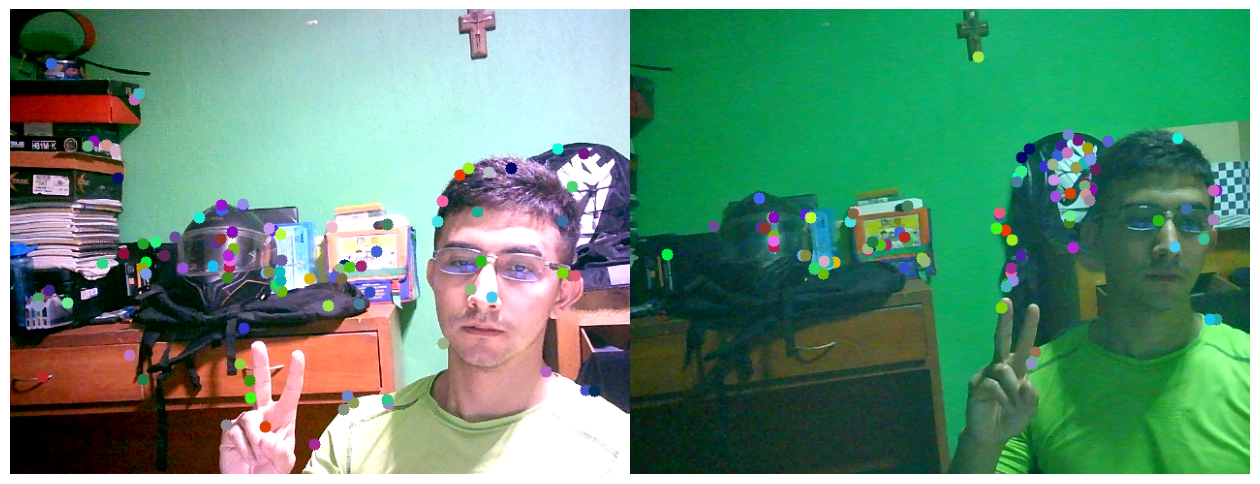

In [21]:
# Mostrar puntos correspondientes entre las dos imagenes
plot_correspondences(distorted_image_bgr_1, distorted_image_bgr_2, uds1, uds2, figsize=(16,10), title='', p_size=6, show_text=False)

#### 5.1.3 BRISK (Binary Robust Invariant Scalable Keypoints) <a class='anchor' id='oppfabrisk'>

In [12]:
"""
Inicializar el detector BRISK
- thresh: Umbral de detección de AGAST. Los valores más bajos hacen que el detector sea muy sensible, generando más puntos clave. Los valores más altos filtran las características más débiles.
- octaves: Número de octavas de detección utilizadas para el espacio de escala. Al establecer este valor a 0 se restringe la detección a una sola escala (deshabilitando la optimización de la invariancia de escala).
- patternScale: Factor de escala aplicado al patrón de muestreo que rodea un punto clave.
"""
brisk = cv2.BRISK_create(
    thresh=30,
    octaves=3,
    patternScale=1.0
)

# Calcular puntos correspondientes entre las dos imagenes
uds1,uds2=corresponding_points(distorted_image_bgr_1, distorted_image_bgr_2, brisk)

# Filtrar solo las mejores correspondencias
uds1=uds1[:100]
uds2=uds2[:100]

# Eliminacion de la distorsion
us1=undistorted_points(uds1, K1, q1)
us2=undistorted_points(uds2, K2, q2)
print(us1.shape)
print(us2.shape)

(100, 2)
(100, 2)


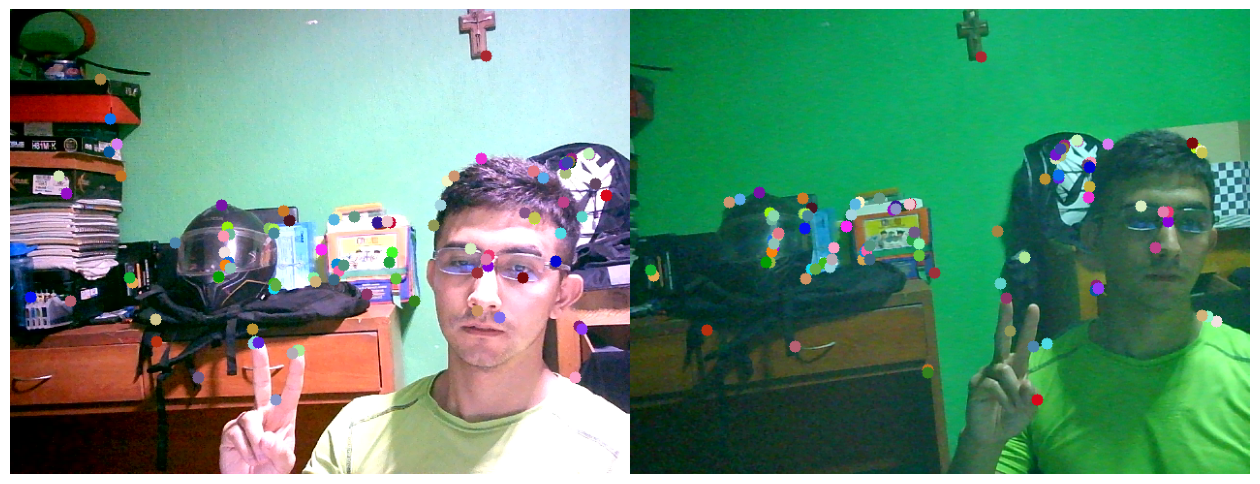

In [13]:
# Mostrar puntos correspondientes entre las dos imagenes
plot_correspondences(distorted_image_bgr_1, distorted_image_bgr_2, uds1, uds2, figsize=(16,10), title='', p_size=6, show_text=False)

## 5.2 Forma manual <a class='anchor' id='oppfm'>

Se eligen pares de puntos correspondientes de forma manual.

Los pasos son los siguientes:
1. Se elige un punto en la imagen izquierda y despues se elige su punto correspondiente en la imagen derecha
2. Se repite el proceso hasta seleccionar la cantidad suficiente de pares de puntos correspondientes
3. Para salir se presiona la tecla 'q'

In [36]:
# Seleccionar puntos correspondientes entre las dos imagenes
uds1,uds2=manual_corresponding_points(distorted_image_bgr_1, distorted_image_bgr_2)

# Eliminacion de la distorsion
us1=undistorted_points(uds1, K1, q1)
us2=undistorted_points(uds2, K2, q2)
print(us1.shape)
print(us2.shape)

(19, 2)
(19, 2)


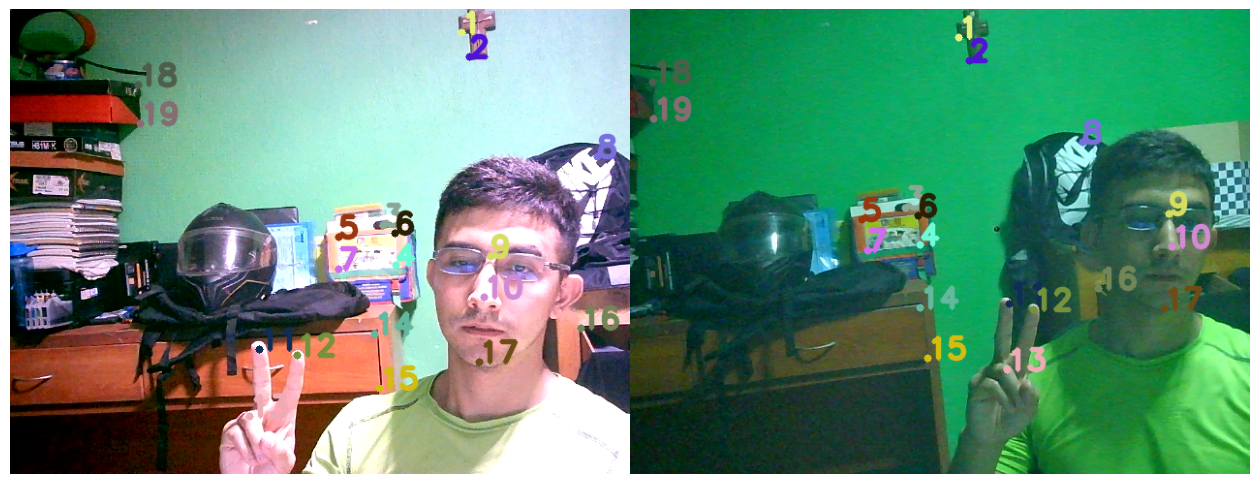

In [37]:
# Mostrar puntos correspondientes entre las dos imagenes
plot_correspondences(distorted_image_bgr_1, distorted_image_bgr_2, uds1, uds2, figsize=(16,10), title='', p_size=4, t_size=3)

# 6. Normalizar coordenadas en el rango [-1,1] <a class='anchor' id='nc'>

In [38]:
# Dimensiones de la imagen 1
h,w,_=distorted_image_bgr_1.shape
# Matriz de normalizacion de la imagen 1
M1=normalization_matrix(w,h)
# Dimensiones de la imagen 2
h,w,_=distorted_image_bgr_2.shape
# Matriz de normalizacion de la imagen 2
M2=normalization_matrix(w,h)

# Puntos normalizados
ums1=(M1 @ np.hstack([us1, np.ones((us1.shape[0], 1))]).T)[0:2,:].T
ums2=(M2 @ np.hstack([us2, np.ones((us2.shape[0], 1))]).T)[0:2,:].T
print(ums1.shape)
print(ums2.shape)

(19, 2)
(19, 2)


# 7. Calcular matriz esencial E <a class='anchor' id='cme'>

OpenCV parte de la siguiente expresion para definir la matriz esencial:
$$
\vec{v_{c2}}=\vec{t_{12}} + T_{12} \vec{v_{c1}}
$$
Dado que los vectores viven en el plano epipolar, se utiliza el triple producto escalar para derivar la restriccion epipolar:
$$
\vec{v_{c2}^T} (\vec{t_{12}} \times T_{12} \vec{v_{c1}})=\vec{v_{c2}^T} ([\vec{t_{12}}]_\times T_{12} \vec{v_{c1}})=\vec{v_{c2}^T} [\vec{t_{12}}]_\times T_{12} \vec{v_{c1}}=\vec{v_{c2}^T} E \vec{v_{c1}}=0
$$
Donde:
$$
E=[\vec{t_{12}}]_\times T_{12} 
$$
Las coordenadas normalizadas en el rango [-1,1] estan dadas por las siguientes ecuaciones:
$$
\vec{u'_{m1}}=M_1 \vec{u'_1}
$$
$$
\vec{u'_{m2}}=M_2 \vec{u'_2}
$$
Para cada camara se tiene lo siguiente:
$$
z_{c1} \vec{u'_1} = K_1 \vec{v_{c1}} \rightarrow \vec{v_{c1}}=z_{c1} K_1^{-1} \vec{u'_1}=z_{c1} K_1^{-1} M_1^{-1} \vec{u'_{m1}}
$$
$$
z_{c2} \vec{u'_2} = K_2 \vec{v_{c2}} \rightarrow \vec{v_{c2}}=z_{c2} K_2^{-1} \vec{u'_2}=z_{c2} K_2^{-1} M_2^{-1} \vec{u'_{m2}}
$$
Por tanto, la restriccion epipolar se puede expresar de la siguiente manera:
$$
(z_{c2} K_2^{-1} M_2^{-1} \vec{u'_{m2}})^T E (z_{c1} K_1^{-1} M_1^{-1} \vec{u'_{m1}})=0
$$
$$
\vec{u'_{m2}}^T (M_2^T)^{-1} (K_2^T)^{-1} E K_1^{-1} M_1^{-1} \vec{u'_{m1}}=0
$$
$$
\vec{u'_{m2}}^T E_n \vec{u'_{m1}}=0
$$
Donde:
$$
E_n=(M_2^T)^{-1} (K_2^T)^{-1} E K_1^{-1} M_1^{-1}
$$
La matriz $E_n$ es la que calcula OpenCV. 

Para recuperar la matriz $E$ se tiene la siguiente expresion:
$$
E=K_2^T M_2^T E_n M_1 K_1
$$
La interpretacion es la siguiente:
- $E_n$ se calcula con puntos 2D normalizados en el rango [-1,1]
- $E$ se calcula con puntos 2D originales

Lineas epipolares:
- Utilizando $E_n$:
    - $\vec{l_{n1}}=E_n^T \vec{u'_{m2}}$
    - $\vec{l_{n2}}=E_n \vec{u'_{m1}}$
- Utilizando $E$:
    - $\vec{l_1}=F^T \vec{u'_2}$
    - $\vec{l_2}=F \vec{u'_1}$
    - Donde:
        - $F=(K_2^T)^{-1} E K_1^{-1}$
     
Las lineas epipolares estan conformadas por un vector $\vec{w}$ ortogonal a la recta y un escalar $b$ de la siguiente manera:
$$
\vec{l}=\begin{pmatrix} 
    \vec{w} \\ 
    b 
\end{pmatrix}=\begin{pmatrix} 
    w_x \\ 
    w_y \\
    b
\end{pmatrix}
$$
     
¿Como funciona RANSAC?
1. Se selecciona de forma aleatoria el minimo numero de pares de puntos correspondientes para calcular la matriz esencial (en este caso 5)
2. Se calcula la matriz esencial utilizando el minimo numero de pares de puntos correspondientes
3. Utilizando la matriz esencial calculada, se miden distancias (en ambas direcciones) entre todos los pares de puntos correspondientes y sus respectivas lineas epipolares
    - Si $\text{distancia} > \text{threshold}$, se considera outlier
    - Si $\text{distancia} \leq \text{threshold}$, se considera inlier
4. Para dicha matriz esencial, se cuenta cuantos inliers se obtuvieron
5. Se repiten los pasos 1) al 4) un numero determinado de veces
6. Se elige la matriz esencial que logro el mayor numero de inliers
7. Se refina la matriz esencial utilizando todos los inliers 

In [39]:
"""
La funcion 'findEssentialMat' calcula una matriz esencial a partir de los puntos correspondientes en dos imágenes.
Esta función estima la matriz esencial basándose en el algoritmo de cinco puntos de Nister.
La geometría epipolar se describe mediante la siguiente ecuación:
[p2;1]' * inv(K)' * E * inv(K) * [p1;1] = 0

Parametros de la funcion:
- points1 (N,2)
- points2 (N,2)
- cameraMatrix
    Esta función asume que points1 y points2 son puntos correspondientes de cámaras con la misma matriz de cámara.
- method
    - cv2.RANSAC (Random Sample Consensus)
    - cv2.LMEDS (Least Median of Squares)
- prob
    Especifica un nivel de confianza (probabilidad) deseado de que la matriz estimada sea correcta.
- threshold
    Se utiliza para identificar inliers y outliers utilizando la restriccion epipolar.
- mask
    Mascara donde 1 indica inlier y 0 indica outlier.
"""
# Umbral que se utiliza en la restriccion epipolar para detectar inliers y outliers
# El umbral es pequeño porque se esta trabajando con las coordenadas normalizadas
threshold=0.001
En,mask=cv2.findEssentialMat(
    points1=ums1, 
    points2=ums2, 
    cameraMatrix=np.eye(3), 
    method=cv2.RANSAC, 
    prob=0.999, 
    threshold=threshold, 
    mask=True
)
E=K2.T @ M2.T @ En @ M1 @ K1

# Mascara
print(f'Mascara de inliers (1) y outliers (0):\n{mask.flatten()}')
# En el caso ideal la matriz esencial deberia tener dos valores singulares iguales y un valor singular igual a cero
U,s,Vh=np.linalg.svd(E)
print(f'Valores singulares de la matriz esencial E:\n{s}')
# print(U)
# print(np.diag(s))
# print(Vh)

Mascara de inliers (1) y outliers (0):
[0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0]
Valores singulares de la matriz esencial E:
[3.10246015e+00 2.15189470e+00 9.01835493e-14]


## 7.1 Error de la matriz esencial <a class='anchor' id='cmee'>

##### Error utilizando las lineas epipolares
$$
\text{Error} = \frac{1}{N} \sum_{n=1}^{N} \frac{1}{2} (d_{n1}^{(n)} + d_{n2}^{(n)})
$$
Donde:
- $d_{n1}^{(n)}$: Distancia entre la linea epipolar $\vec{l_{n1}}$ y el punto $\vec{u'^{(n)}_{m1}}$.
- $d_{n2}^{(n)}$: Distancia entre la linea epipolar $\vec{l_{n2}}$ y el punto $\vec{u'^{(n)}_{m2}}$.

Este error es mas util y cada error individual se utiliza para la identificacion de inliers y outliers en el algoritmo RANSAC. 

In [40]:
# Filtramos buenas correspondencias
filtered_ums1=ums1[mask.flatten().astype(bool)]
filtered_ums2=ums2[mask.flatten().astype(bool)]

# Distancia entre un punto y una recta
d=lambda l,p: np.abs(np.dot(l, np.hstack([p, 1]))) / np.linalg.norm(l[0:2])

# Numero de buenas correspondencias
N=filtered_ums1.shape[0]
error=0
for i in range(N):
    # Lineas epipolares (normalizadas)
    ln1=(En.T @ np.hstack([filtered_ums2[i], 1])[:,None]).flatten()
    ln2=(En @ np.hstack([filtered_ums1[i], 1])[:,None]).flatten()
    # Se calculan las distancias en ambas direcciones
    # Distancia entre la recta ln1 y el punto um1
    dn1=d(ln1, filtered_ums1[i])
    # Distancia entre la recta ln2 y el punto um2
    dn2=d(ln2, filtered_ums2[i])
    # Distancia promedio
    d_mean=(dn1 + dn2) / 2
    error+=d_mean
error/=N
print(f'Error: {error}')

Error: 0.0003337151025504194


##### Error utilizando la restriccion epipolar
$$
\text{Error} = \frac{1}{N} \sum_{n=1}^{N} \lvert \vec{u'^{(n)}_{m2}}^T E_n \vec{u'^{(n)}_{m1}} \rvert
$$

In [41]:
# Filtramos buenas correspondencias
filtered_ums1=ums1[mask.flatten().astype(bool)]
filtered_ums2=ums2[mask.flatten().astype(bool)]

# Evaluamos cada buena correspondencia en la restriccion epipolar
# Numero de buenas correspondencias
N=filtered_ums1.shape[0]
error=0
for i in range(N):
    um1_=np.hstack([filtered_ums1[i], 1])[:,None]
    um2_=np.hstack([filtered_ums2[i], 1])[:,None]
    error+=np.abs((um2_.T @ En @ um1_).item())
error/=N
print(f'Error: {error}')

Error: 0.00023210513367581155


## 7.2 Lineas epipolares sobre coordenadas normalizadas <a class='anchor' id='cmeln'>

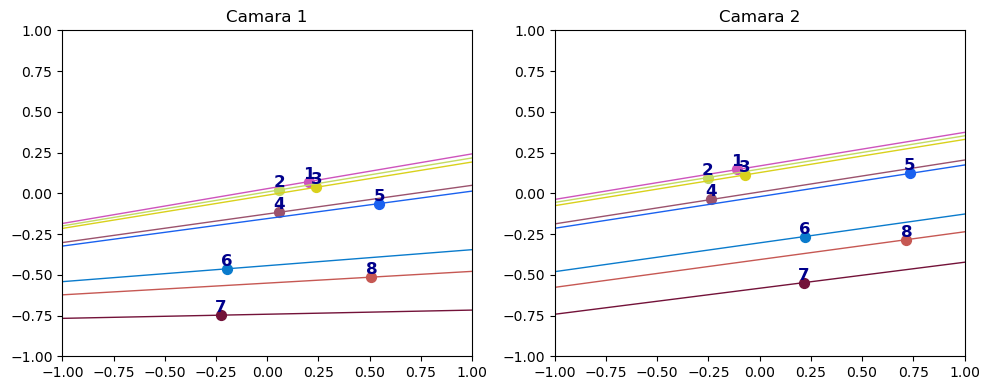

In [42]:
"""
NOTA: 
Dado que los sistemas de coordenadas de imagen y de matplotlib son diferentes, a las componentes 
en Y se les agrega un signo menos porque se pasa del sistema de coordenadas de imagen al de matplotlib.

Esto se hace para visualizar de forma correcta las lineas epipolares en matplotlib.
"""
# Filtramos buenas correspondencias
filtered_ums1=ums1[mask.flatten().astype(bool)]
filtered_ums2=ums2[mask.flatten().astype(bool)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.set_title("Camara 1")
ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax2.set_title("Camara 2")
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
# Funcion para graficar las lineas epipolares
y=lambda l,x: -(l[0] * x + l[2]) / l[1]
# Numero de buenas correspondencias
N=filtered_ums1.shape[0]
for i in range(N):
    # Lineas epipolares (normalizadas)
    ln1=(En.T @ np.hstack([filtered_ums2[i], 1])[:,None]).flatten()
    ln2=(En @ np.hstack([filtered_ums1[i], 1])[:,None]).flatten()
    # Color para la correspondencia
    rgb_color=tuple(np.random.random(3))
    # Mostrar puntos
    ax1.scatter(filtered_ums1[i,0], -filtered_ums1[i,1], color=rgb_color, s=50) 
    ax2.scatter(filtered_ums2[i,0], -filtered_ums2[i,1], color=rgb_color, s=50)     
    # Mostrar lineas
    ax1.plot([-1, 1], [-y(ln1,-1), -y(ln1,1)], color=rgb_color, linewidth=1.0)
    ax2.plot([-1, 1], [-y(ln2,-1), -y(ln2,1)], color=rgb_color, linewidth=1.0)
    # Mostrar texto
    ax1.text(filtered_ums1[i,0], -filtered_ums1[i,1], f"{i + 1}", fontsize=12, color='darkblue', fontweight='bold', ha='center', va='bottom')
    ax2.text(filtered_ums2[i,0], -filtered_ums2[i,1], f"{i + 1}", fontsize=12, color='darkblue', fontweight='bold', ha='center', va='bottom')
plt.tight_layout()                          
plt.show()

## 7.3 Lineas epipolares sobre coordenadas originales <a class='anchor' id='cmelo'>

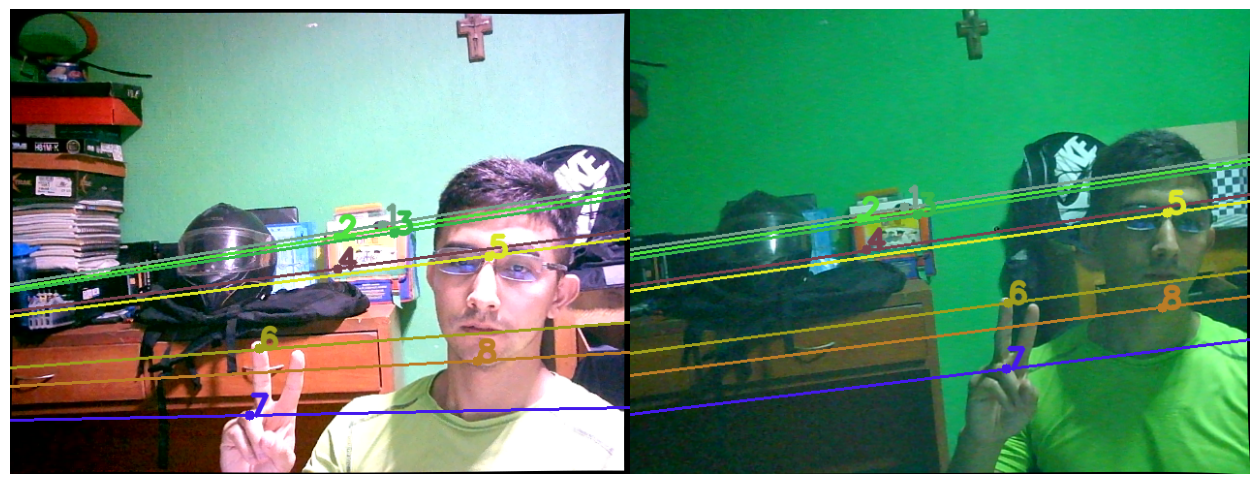

In [43]:
# Filtramos buenas correspondencias
filtered_us1=us1[mask.flatten().astype(bool)]
filtered_us2=us2[mask.flatten().astype(bool)]

# Eliminamos la distorsion en las imagenes
undistorted_image_bgr_1=cv2.undistort(distorted_image_bgr_1, K1, q1, None, K1)
undistorted_image_bgr_2=cv2.undistort(distorted_image_bgr_2, K2, q2, None, K2)
# Matriz fundamental
F=np.linalg.inv(K2.T) @ E @ np.linalg.inv(K1)
# Funcion para graficar las lineas epipolares
y=lambda l,x: -(l[0] * x + l[2]) / l[1]
# Numero de buenas correspondencias
N=filtered_us1.shape[0]
for i in range(N):
    # Lineas epipolares
    l1=(F.T @ np.hstack([filtered_us2[i], 1])[:,None]).flatten()
    l2=(F @ np.hstack([filtered_us1[i], 1])[:,None]).flatten()
    # Color para la correspondencia
    color_bgr=tuple(np.random.randint(0,255,3,dtype='uint8').tolist())
    # Mostrar puntos
    undistorted_image_bgr_1=cv2.circle(undistorted_image_bgr_1, filtered_us1[i].astype(int), 5, color_bgr, -1)
    undistorted_image_bgr_2=cv2.circle(undistorted_image_bgr_2, filtered_us2[i].astype(int), 5, color_bgr, -1)
    # Mostrar lineas
    h,w,_=undistorted_image_bgr_1.shape
    undistorted_image_bgr_1=cv2.line(undistorted_image_bgr_1, (0,int(y(l1,0))), (w,int(y(l1,w))), color_bgr, 2)
    h,w,_=undistorted_image_bgr_2.shape
    undistorted_image_bgr_2=cv2.line(undistorted_image_bgr_2, (0,int(y(l2,0))), (w,int(y(l2,w))), color_bgr, 2)
    # Mostrar texto
    undistorted_image_bgr_1=cv2.putText(undistorted_image_bgr_1, f'{i + 1}', filtered_us1[i].astype(int), cv2.FONT_HERSHEY_SIMPLEX, 1, color_bgr, 3, cv2.LINE_AA)
    undistorted_image_bgr_2=cv2.putText(undistorted_image_bgr_2, f'{i + 1}', filtered_us2[i].astype(int), cv2.FONT_HERSHEY_SIMPLEX, 1, color_bgr, 3, cv2.LINE_AA)
image_rgb=cv2.cvtColor(cv2.hconcat([undistorted_image_bgr_1, undistorted_image_bgr_2]), cv2.COLOR_BGR2RGB)
fig=plt.figure(figsize=(16,10))
plt.title('')
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

# 8. Recuperar pose relativa (R,t) <a class='anchor' id='rpr'>

Solo elegir una opcion de las siguientes:
- Comprobar solucion fisicamente correcta de forma automatica
- Comprobar solucion fisicamente correcta de forma manual
  
De entre las cuatro posibles soluciones, solo una es físicamente correcta, y corresponde a aquella solución donde el punto 3D esta situado delante de las cámaras. En términos generales, la solución correcta es aquella que hace que la solución optima del siguiente problema de minimización sea mayor a cero ($z_{c2} > 0$ y $z_{c1} > 0$) para algún par de puntos 2D correspondientes:
$$
\min_{z_{c2},z_{c1}} g(z_{c2},z_{c1})=\lVert \vec{v_{c2}} - (\vec{t_{12}} + T_{12} \vec{v_{c1}}) \rVert ^ 2
$$
Donde:
$$
\vec{v_{c2}}=z_{c2} K_2^{-1} \vec{u_2'}=z_{c2} \vec{v'_{n2}}
$$
$$
\vec{v_{c1}}=z_{c1} K_1^{-1} \vec{u_1'}=z_{c1} \vec{v'_{n1}}
$$
$$
\vec{v'_{n2}}=\begin{pmatrix} 
    \vec{v_{n2}} \\ 
    1 
\end{pmatrix}=\begin{pmatrix} 
    \frac{x_{c2}}{z_{c2}} \\ 
    \frac{y_{c2}}{z_{c2}} \\
    1
\end{pmatrix}
$$
$$
\vec{v'_{n1}}=\begin{pmatrix} 
    \vec{v_{n1}} \\ 
    1 
\end{pmatrix}=\begin{pmatrix} 
    \frac{x_{c1}}{z_{c1}} \\ 
    \frac{y_{c1}}{z_{c1}} \\
    1
\end{pmatrix}
$$
Los puntos 2D $\vec{v_{n2}}$ y $\vec{v_{n1}}$ estan expresados en los planos de imagen normalizados de las respectivas camaras.

## 8.1 Comprobar solucion fisicamente correcta de forma automatica <a class='anchor' id='rpra'>

Se utiliza una funcion de OpenCV para recuperar la pose relativa.

In [44]:
# Puntos 2D expresados en el plano de imagen normalizado
vns1=(np.linalg.inv(K1) @ np.hstack([us1, np.ones((us1.shape[0],1))]).T)[[0,1],:].T
vns2=(np.linalg.inv(K2) @ np.hstack([us2, np.ones((us2.shape[0],1))]).T)[[0,1],:].T
_, T12, t12, _ = cv2.recoverPose(E=E, points1=vns1, points2=vns2, cameraMatrix=np.eye(3), mask=mask)

## 8.2 Comprobar solucion fisicamente correcta de forma manual <a class='anchor' id='rprm'>

Se utiliza una funcion propia para recuperar la pose relativa.

In [47]:
# Puntos 2D expresados en el plano de imagen normalizado
vns1=(np.linalg.inv(K1) @ np.hstack([us1, np.ones((us1.shape[0],1))]).T)[[0,1],:].T
vns2=(np.linalg.inv(K2) @ np.hstack([us2, np.ones((us2.shape[0],1))]).T)[[0,1],:].T
T12,t12=recover_pose(E, vns1, vns2, mask=mask)

# 9. Resultados <a class='anchor' id='r'>

Los resultados obtenidos provienen de la siguiente ecuacion:
$$
\vec{v_{c2}}=\vec{t_{12}} + T_{12} \vec{v_{c1}}
$$
Con la excepcion de que solo conocemos la direccion de traslacion pero no la maginitud verdadera. 

Partiendo de la ecuacion anterior, es posible expresarla de la siguiente manera:
$$
\vec{v'_{c2}}=\begin{pmatrix} 
    T_{12} & \vec{t_{12}} \\ 
    0^T & 1
\end{pmatrix} \vec{v'_{c1}}=H_{12} \vec{v'_{c1}}
$$
La relacion inversa quedaria de la siguiente manera:
$$
\vec{v'_{c1}}=H_{12}^{-1} \vec{v'_{c2}}=H_{21} \vec{v'_{c2}}
$$
Por tanto:
$$
H_{21}=\begin{pmatrix} 
    T_{21} & \vec{t_{21}} \\ 
    0^T & 1
\end{pmatrix}=H_{12}^{-1}=\begin{pmatrix} 
    T_{12}^T & -T_{12}^T \vec{t_{12}} \\ 
    0^T & 1
\end{pmatrix}
$$
De lo anterior obtenemos lo siguiente:
$$
T_{21}=T_{12}^T
$$
$$
\vec{t_{21}}=-T_{12}^T \vec{t_{12}}
$$
El objetivo de calcular $T_{21}$ y $\vec{t_{21}}$ es que estamos interesados en como esta rotado y trasladado el sistema de coordenadas de la camara 2 con respecto al sistema de coordenadas de la camara 1.

In [48]:
# Rotacion y traslacion del sistema de coordenadas de la camara 2 con respecto al sistema de coordenadas de la camara 1
T21=T12.T
t21=-T12.T @ t12

# Se muestra como es que se desplazo y roto el sistema de coordenadas de la camara 2 con respecto al sistema de coordenadas de la camara 1
fig=plot_recovered_pose(T21, t21)
fig.show()

In [46]:
# Solo por curiosidad, estas serian las 4 posibles soluciones (solo una de ellas es la correcta)
R1,R2,t=cv2.decomposeEssentialMat(E)
for index,(T12,t12) in enumerate([
    (R1,t), 
    (R1,-t), 
    (R2,t), 
    (R2,-t)
]):
    T21=T12.T
    t21=-T12.T @ t12
    
    fig=plot_recovered_pose(T21, t21)
    fig.show()